In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, jv, kv
from scipy.integrate import simpson
from scipy.special import erf

# GLobal parameters
omega   = -0.99 # Inflation
G       = 1.0
D0      = 1.0
hbar    = 1.0

PHI_LIMIT   = 0.5
NK          = 500
K_MIN       = 0.01
N_PHI_VALS  = 300

SCALE_FACTOR = np.linspace(0.1, 20, 250)
R_GRID_FULL  = np.linspace(0.2, 5.0, 100)

# Function for the background energy density
def rho(a):
    return D0 * a**(-3 * (1 + omega))

# Function for the conformal Hubble rate
def H_conf(a):
    return np.sqrt(8 * np.pi * G / 3 * rho(a) * a**2)

# Function for conformal time as a function of the scale factor
def eta_from_a(a):
    pref = (2 / (1 + 3 * omega)) * np.sqrt(3 / (8 * np.pi * G * D0))
    return pref * a**((1 + 3 * omega) / 2)

# Function for getting the dS for WKB approximation
def dS_from_a(a):
    return np.sqrt((3 / (2 * np.pi * G)) * a**4 * rho(a))

# Function for computing the WKB approximation range
def compute_wkb_valid_a(scale_factor, epsilon_threshold=0.1):
    dS   = dS_from_a(scale_factor)
    d2S  = np.gradient(dS, scale_factor)
    eps  = np.abs(d2S / dS**2)
    return scale_factor[eps < epsilon_threshold]

# Function for calculating the classical metric perturbation in Fourier space
def phi_k_classical(k, eta_val):
    B_val    =  (5 + 3 * omega) / (2 * (1 + 3 * omega))
    eta_abs  = np.abs(eta_val)
    if omega < 0:
        x = np.sqrt(abs(omega)) * k * eta_abs
        return eta_abs**(-B_val) * iv(B_val, x)
    else:
        x = np.sqrt(omega) * k * eta_abs
        return eta_abs**(-B_val) * jv(B_val, x)

# Function for calculating the classical perturbation in real space
def phi_classical(k, eta_val, r):
    phi_k_vals = phi_k_classical(k, eta_val)
    integrand  = k * phi_k_vals * np.sin(k * r)
    return simpson(integrand, x=k) / (2 * np.pi**2 * r)

# Function for determining which r's are valid in the linearity condition
def compute_phi_grid(r_grid, a_grid):
    phi_ar = np.zeros((len(r_grid), len(a_grid)))
    for i, r in enumerate(r_grid):
        for j, a in enumerate(a_grid):
            eta_val = eta_from_a(a)
            k       = np.linspace(K_MIN, H_conf(a), NK)
            phi_ar[i, j] = phi_classical(k, eta_val, r)
    return phi_ar

# Function for filtering all valid r's of the linearty condition
def filter_valid_r(phi_ar, r_grid):
    mask   = np.all(np.abs(phi_ar) < PHI_LIMIT, axis=1)
    return phi_ar[mask], r_grid[mask]

# Function for picking five random r's for plotting purposes
def select_r_indices(r_grid, n=5):
    selected_r = np.linspace(r_grid.min(), r_grid.max(), min(n, len(r_grid)))
    return [np.argmin(np.abs(r_grid - r)) for r in selected_r]

# Function for calcualting B
def B_val():
    return (5 + 3 * omega) / (2 * (1 + 3 * omega))

# Function for calculating R
def R_val():
    return (6 + 2 * omega) / (1 + 3 * omega)

# Function for calculating beta
def beta_val():
    return 1 / (4 * hbar)

# Function for calculating alpha
def alpha_val(eta_0, k):
    return B_val() / (eta_0 * np.sqrt(np.abs(omega)) * k)

# Function for easy access to the IB Bessel function
def I_B(k, eta_val):
    x = np.sqrt(abs(omega)) * k * np.abs(eta_val)
    return iv(B_val(), x)

# Function for easy access to the KB Bessel function
def K_B(k, eta_val):
    x = np.sqrt(abs(omega)) * k * np.abs(eta_val)
    return kv(B_val(), x)

# Function for calculating the numerical eta derivative of the Bessel function
def dBessel_deta_numeric(func, k, eta_val, h=1e-6):
    return (func(k, eta_val + h) - func(k, eta_val - h)) / (2 * h)

# Function for calculating the initial conditions r-ratio
def ratio_r(k, eta_0):
    a_v   = alpha_val(eta_0, k)
    b_v   = beta_val()
    i_b   = I_B(k, eta_0)
    k_b   = K_B(k, eta_0)
    dI    = dBessel_deta_numeric(I_B, k, eta_0)
    dK    = dBessel_deta_numeric(K_B, k, eta_0)
    num   = (a_v - 1j * b_v) * k_b - dK
    den   = dI - (a_v + 1j * b_v) * i_b
    return num / den

# Function for calculating the F ratio for the Ak for any given eta
def ratioF(k, eta_val, eta_0):
    r_k  = ratio_r(k, eta_0)
    i_b  = I_B(k, eta_val)
    k_b  = K_B(k, eta_val)
    dI   = dBessel_deta_numeric(I_B, k, eta_val)
    dK   = dBessel_deta_numeric(K_B, k, eta_val)
    num  = r_k * dI + dK
    den  = r_k * i_b + k_b
    return num / den

# Function for calculating the Ak for any given eta and k
def A_k(k, eta_val, eta_0):
    abs_eta = np.abs(eta_val)
    R_v     = R_val()
    B_v     = B_val()
    prefactor = (2 * abs_eta**R_v * np.exp(-1j * np.pi * R_v)) / 1j
    brackets  = (-B_v / eta_val) + np.sqrt(np.abs(omega)) * k * ratioF(k, eta_val, eta_0)
    return prefactor * brackets

# Function for getting the uncertainty in Fourier space
def sigma_k_squared(k, eta_val, eta_0):
    return 1 / (2 * np.real(A_k(k, eta_val, eta_0)))

# Function for getting the uncertainty in real space
def sigma_x_squared(k, eta_val, eta_0):
    sig_k   = sigma_k_squared(k, eta_val, eta_0)
    integrand = k**2 * sig_k
    return simpson(integrand, x=k) / (2 * np.pi**2)

# Function for calculating the distribution in real space
def gaussian_wavefunction(phi_var, phi_cl, sigma_x_sq):
    norm = 1 / np.sqrt(2 * np.pi * sigma_x_sq)
    return norm * np.exp(-((phi_var - phi_cl)**2) / (2 * sigma_x_sq))

# Function for calculating the error in a Gaussian
def gaussian_cdf(x):
    return 0.5 * (1 + erf(x / np.sqrt(2)))

# Function for calculating the probability of the distribution within the classical limits
def prob_inside(phi_cl, sigma):
    a = (PHI_LIMIT - phi_cl) / sigma
    b = (-PHI_LIMIT - phi_cl) / sigma
    return gaussian_cdf(a) - gaussian_cdf(b)

# Function for calculating the probability of the distirbution outside the classical limits
def prob_outside(phi_cl, sigma):
    return 1.0 - prob_inside(phi_cl, sigma)

# Function for going over every value of eta and determining the classical perturbation value, the uncertainy and ratio
def sweep_eta(r, a_grid, eta_0):
    eta_list     = []
    phi_cl_list  = []
    sig_sq_list  = []
    ratio_list   = []

    EPS = 1e-12
    MAX_RATIO = 1e3

    for a in a_grid:
        eta_val = eta_from_a(a)
        k = np.linspace(K_MIN, H_conf(a), NK)
        phi_cl = phi_classical(k, eta_val, r)
        sig_sq = sigma_x_squared(k, eta_val, eta_0)
        p_ratio = np.nan # Initialise to nan values

        if np.isfinite(sig_sq) and sig_sq > EPS:
            sigma = np.sqrt(sig_sq)

            p_in  = prob_inside(phi_cl, sigma)
            p_out = prob_outside(phi_cl, sigma)

            # Safety feature to avoid dividing by 0
            if p_in > EPS:
                p_ratio = p_out / p_in
                
                # Safety feature to avoid enormous blow up from small prob_in 
                if np.isfinite(p_ratio):
                    p_ratio = min(p_ratio, MAX_RATIO)
                else:
                    p_ratio = np.nan

        eta_list.append(eta_val)
        phi_cl_list.append(phi_cl)
        sig_sq_list.append(sig_sq)
        ratio_list.append(p_ratio)

    return (np.array(eta_list), np.array(phi_cl_list), np.array(sig_sq_list), np.array(ratio_list))

# Function for plotting the classical perturbation with 5 representative r's against a
def plot_phi_vs_a(a_grid, phi_ar, r_grid, selected_idx):
    plt.figure(figsize=(10, 6))
    for idx in selected_idx:
        plt.plot(a_grid, phi_ar[idx], label=f"r={r_grid[idx]:.2f}")
    plt.axhline( PHI_LIMIT, color="red", linestyle="--")
    plt.axhline(-PHI_LIMIT, color="red", linestyle="--")
    plt.xlim(0, a_grid.max() + 0.5)
    plt.ylim(-PHI_LIMIT - 0.1, PHI_LIMIT + 0.1)
    plt.xlabel("Scale factor a (WKB valid)")
    plt.ylabel(r"$\phi(a,r)$")
    plt.title("Metric perturbation vs. scale factor in WKB-valid regime")
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# Function for plotting the classical perturbation with 5 representative r's against eta
def plot_phi_vs_eta(eta_vals, phi_ar, r_grid, selected_idx):
    plt.figure(figsize=(10, 6))
    for idx in selected_idx:
        plt.plot(eta_vals, phi_ar[idx], linestyle="-", label=f"r={r_grid[idx]:.2f}")
    plt.ylim(-PHI_LIMIT - 0.1, PHI_LIMIT + 0.1)
    plt.axhline( PHI_LIMIT, color="red", linestyle="--")
    plt.axhline(-PHI_LIMIT, color="red", linestyle="--")
    plt.xlabel("Conformal time η (WKB valid)")
    plt.ylabel(r"$\phi(\eta,r)$")
    plt.title("Metric perturbation vs. conformal time in WKB-valid regime")
    plt.grid(True)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# Function for plotting a heatmap for the classical perturbation to see the behavior of r and a
def plot_phi_heatmap(a_grid, r_grid, phi_ar):
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(a_grid, r_grid, phi_ar, shading='auto', cmap='viridis')
    plt.colorbar(label=r"$\phi$")
    plt.xlabel("Scale factor a (WKB valid)")
    plt.ylabel("r")
    plt.title(r"Metric perturbation $\phi(a,r)$ in WKB-valid regime")
    plt.tight_layout()
    plt.show()

# Function for plotting the distribution against phi for a single r and eta value
def plot_psi2_vs_phi(a, r, eta_0):
    eta_val  = eta_from_a(a)
    k        = np.linspace(K_MIN, H_conf(a), NK)
    phi_cl   = phi_classical(k, eta_val, r)
    sig_sq   = sigma_x_squared(k, eta_val, eta_0)

    phi_range = np.linspace(-1, 1, N_PHI_VALS)
    psi_vals  = gaussian_wavefunction(phi_range, phi_cl, sig_sq)

    plt.figure(figsize=(8, 5))
    plt.plot(phi_range, psi_vals, label=r"$|\psi_2|^2$")
    plt.axvline(-PHI_LIMIT, color="red", linestyle="--", label="-1/2")
    plt.axvline( PHI_LIMIT, color="red", linestyle="--", label="+1/2")
    plt.xlabel("φ")
    plt.ylabel(r"$|\psi_2|^2$")
    plt.title(f"Quantum distribution at η={eta_val:.3f}, r={r}")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return phi_range, psi_vals, phi_cl, sig_sq, eta_val

# Function for plotting the ratio and uncertainty values against eta at a fixed r
def plot_eta_sweep(eta_vals, sigma_x_sq_vals, ratio_vals, r):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color1 = "steelblue"
    color2 = "darkorange"

    ax1.plot(eta_vals, sigma_x_sq_vals, color=color1, lw=2, label=r"$\sigma^2_x$")
    ax1.set_xlabel("Conformal time η")
    ax1.set_ylabel(r"$\sigma^2_x$", color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    ax2.plot(eta_vals, ratio_vals, color=color2, lw=2, linestyle="--", label=r"$P(|\phi|>1/2)\,/\,P(|\phi|<1/2)$")
    ax2.set_ylabel(r"$P(|\phi|>1/2)\,/\,P(|\phi|<1/2)$", color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"Quantum uncertainty and probability ratio vs conformal time  (r = {r:.3f}, ω = {omega})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Function for plotting the heatmap for the probability ratio
def plot_ratio_heatmap(eta_vals, r_vals, R_matrix):
    R_safe = np.nan_to_num(R_matrix, nan=1e-12, posinf=1e12, neginf=1e-12)
    R_safe = np.clip(R_safe, 1e-12, 1e12)

    # Go to log scale for better visualisation
    logR = np.log10(R_safe)

    # Shift such that the minimum value is at 0
    logR_shifted = logR - np.nanmin(logR)

    plt.figure(figsize=(10,6))

    plt.pcolormesh(eta_vals, r_vals, logR_shifted, shading="auto", cmap="viridis")
    plt.colorbar(label=r"$\log_{10}(P_{\mathrm{out}}/P_{\mathrm{in}})$")
    plt.xlabel("Conformal time η")
    plt.ylabel("r")
    plt.title("Probability ratio (log scale)")
    plt.tight_layout()
    plt.show()

# Function for getting the uncertainty in Fourier space for each eta and r
def sigma_k_grid(eta_vals, k_vals, eta_0):
    sig = np.zeros((len(eta_vals), len(k_vals)))

    for i, eta_val in enumerate(eta_vals):
        for j, k in enumerate(k_vals):
            sig[i, j] = sigma_k_squared(k, eta_val, eta_0)

    return sig

# Function for plotting the 2D plot of the uncertainty in Fourier space
def plot_sigma_k_heatmap(eta_vals, k_vals, sigma_k_mat):
    sig_safe = np.nan_to_num(sigma_k_mat, nan=0.0, posinf=1e6, neginf=0.0)

    log_sig = np.log10(sig_safe + 1e-30)

    plt.figure(figsize=(10,6))
    plt.pcolormesh(eta_vals, k_vals, log_sig.T, shading="auto", cmap="viridis")
    plt.colorbar(label=r"$\log_{10}(\sigma_k^2)$")
    plt.xlabel("Conformal time η")
    plt.ylabel("k")
    plt.title("Quantum uncertainty in Fourier space σ_k² (log scale)")
    plt.tight_layout()
    plt.show()

# Function of the logic to run the classical part
def run_classical_part(scale_factor, r_grid_full):
    a_grid = compute_wkb_valid_a(scale_factor) # calculate the a-range in the WKB regime
    print(f"WKB range: {a_grid.min():.3f} - {a_grid.max():.3f}")

    # Filter out all r's that are valid in the WKB range
    phi_ar        = compute_phi_grid(r_grid_full, a_grid)
    phi_ar, r_grid = filter_valid_r(phi_ar, r_grid_full)
    print(f"Valid r-range: {r_grid.min():.3f} - {r_grid.max():.3f}")

    selected_idx = select_r_indices(r_grid)

    eta_vals = eta_from_a(a_grid)

    # Plot all the figures for analysis
    plot_phi_vs_a(a_grid, phi_ar, r_grid, selected_idx)
    plot_phi_vs_eta(eta_vals, phi_ar, r_grid, selected_idx)
    plot_phi_heatmap(a_grid, r_grid, phi_ar)

    return a_grid, r_grid, phi_ar

# Function for running the quantum distribution for 5 different eta at a fixed r
def run_distribution_eta(a_grid, r, n_samples=5):
    eta_0 = eta_from_a(a_grid.min())

    # Select 5 random values evenly spaced
    a_samples = np.linspace(a_grid.min(), a_grid.max(), n_samples)

    # Plot and print the distribution and values
    for a_sample in a_samples:
        phi_range, psi_vals, phi_cl, sig_sq, eta_val = plot_psi2_vs_phi(a_sample, r, eta_0)
        print(f"eta={eta_val:.5f}, phi_cl={phi_cl:.5f}, sigma_x²={sig_sq:.5f}")

    return phi_range, psi_vals, phi_cl, sig_sq

# Function for going over all eta values at a fixed r and determining the probability ratio
def run_prob_ratio_all_eta(a_grid, r):
    eta_0 = eta_from_a(a_grid.min())
    eta_vals, phi_cl_vals, sig_sq_vals, ratio_vals = sweep_eta(r, a_grid, eta_0)
    plot_eta_sweep(eta_vals, sig_sq_vals, ratio_vals, r)

    return eta_vals, phi_cl_vals, sig_sq_vals, ratio_vals

# Function for the logic of getting the uncertainty in Fourier space
def run_uncertainty_Fourier(a_grid, Nk):
    eta_0 = eta_from_a(a_grid.min())
    eta_vals = np.array([eta_from_a(a) for a in a_grid])

    k_max = np.max([H_conf(a) for a in a_grid])
    k_vals = np.linspace(K_MIN, k_max, Nk)

    sigma_k_mat = sigma_k_grid(eta_vals, k_vals, eta_0)

    return eta_vals, k_vals, sigma_k_mat

# Function for the logic of getting the probability ratio at each eta and r
def run_prob_ratio_all_r(a_grid, r_grid):
    eta_0 = eta_from_a(a_grid.min())
    eta_fixed = np.array([eta_from_a(a) for a in a_grid])
    R_matrix = np.zeros((len(r_grid), len(eta_fixed)))

    for i, r in enumerate(r_grid):
        _, _, _, ratio_vals = sweep_eta(r, a_grid, eta_0)
        ratio_vals = np.array(ratio_vals)
        R_matrix[i, :] = ratio_vals

    return eta_fixed, r_grid, R_matrix


WKB range: 3.137 - 20.000
Valid r-range: 0.976 - 5.000


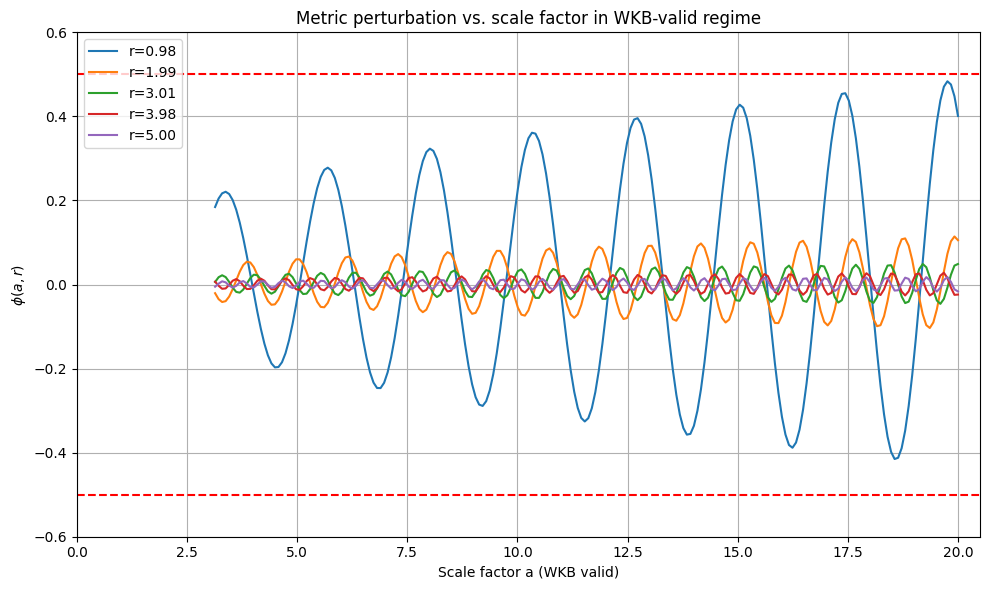

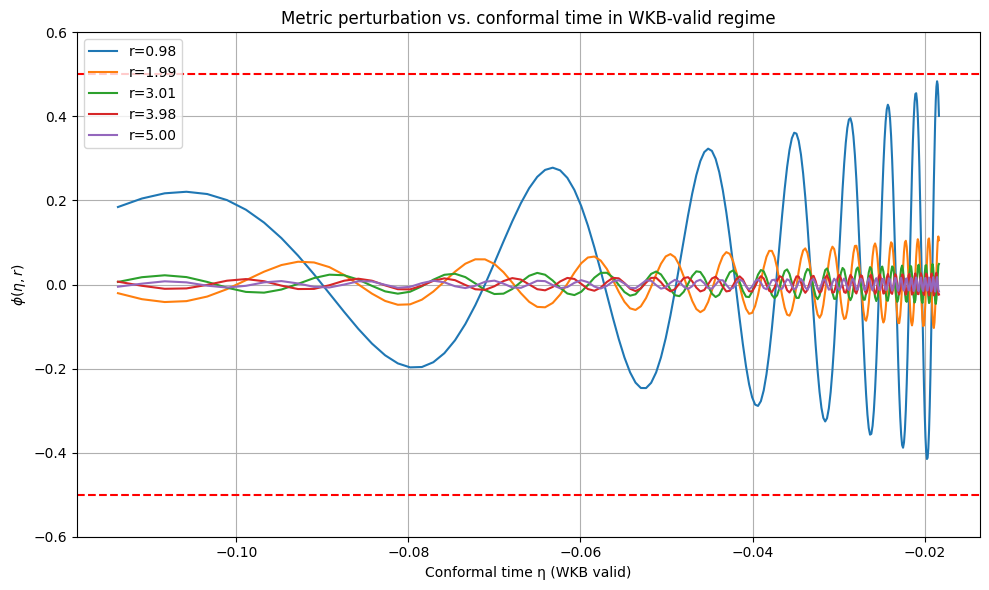

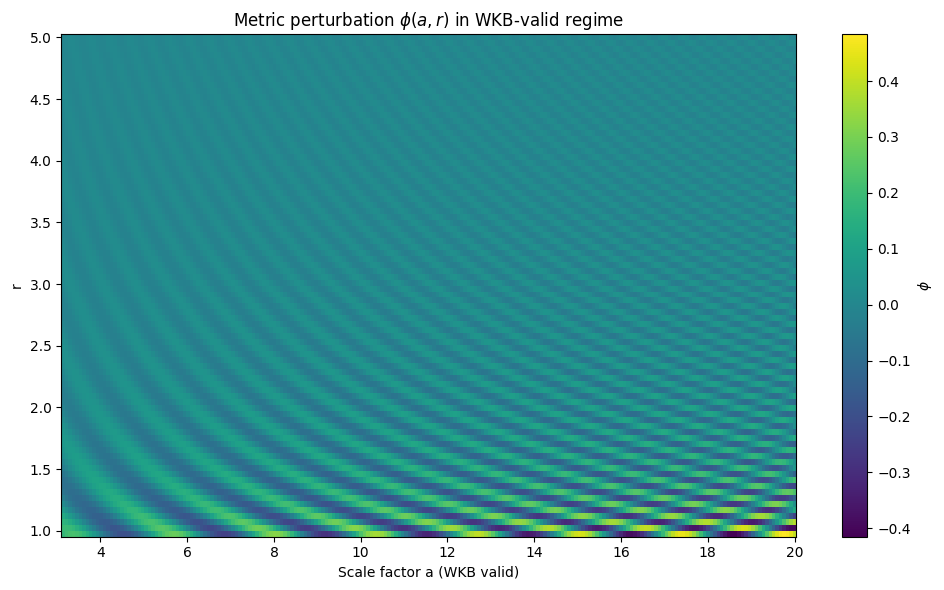

In [61]:
# Run the first classical part
a_grid, r_grid, phi_ar = run_classical_part(SCALE_FACTOR, R_GRID_FULL)

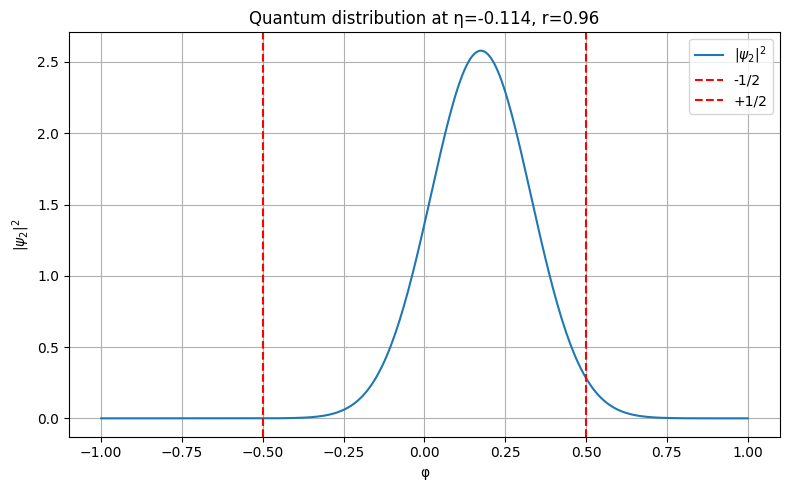

eta=-0.11375, phi_cl=0.17465, sigma_x²=0.02392


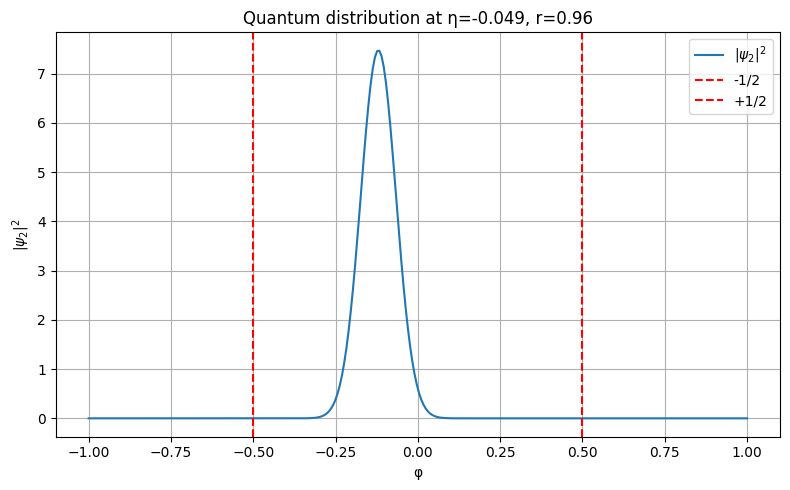

eta=-0.04915, phi_cl=-0.11993, sigma_x²=0.00285


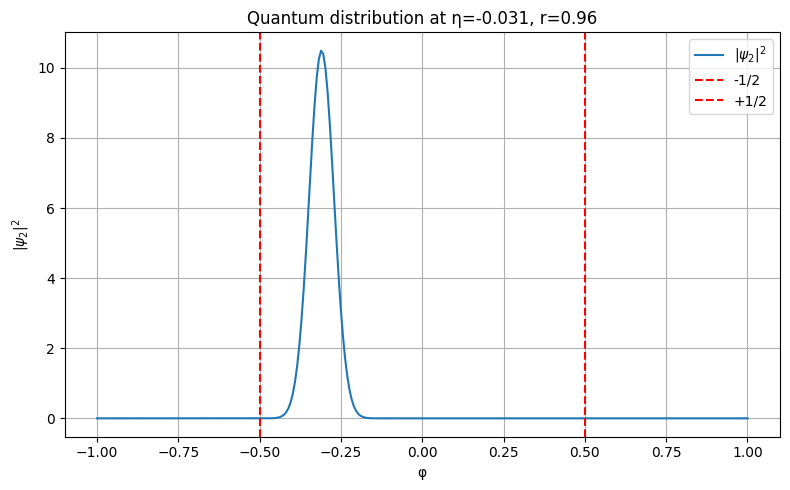

eta=-0.03145, phi_cl=-0.30962, sigma_x²=0.00144


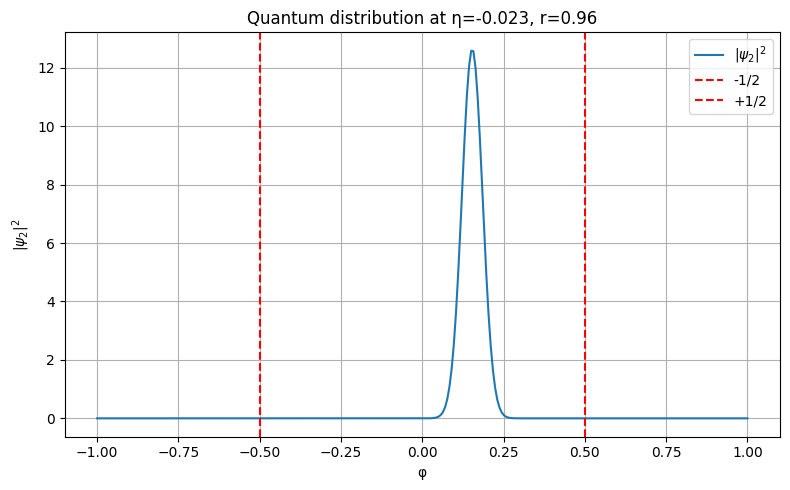

eta=-0.02316, phi_cl=0.15365, sigma_x²=0.00100


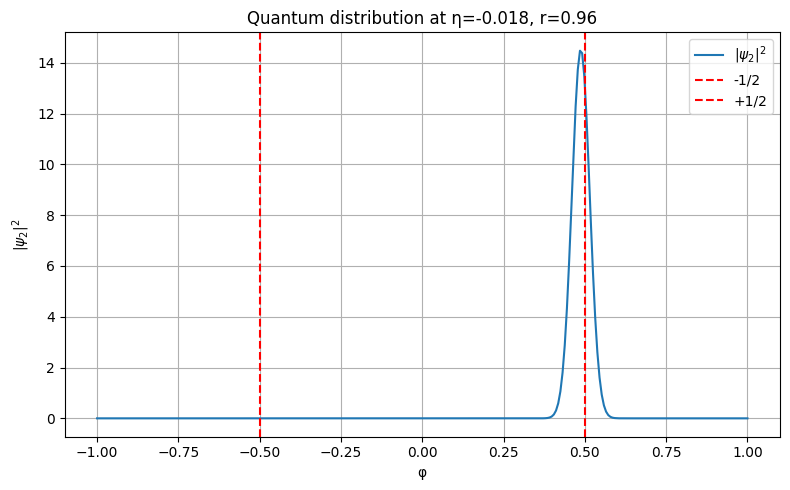

eta=-0.01834, phi_cl=0.48754, sigma_x²=0.00075


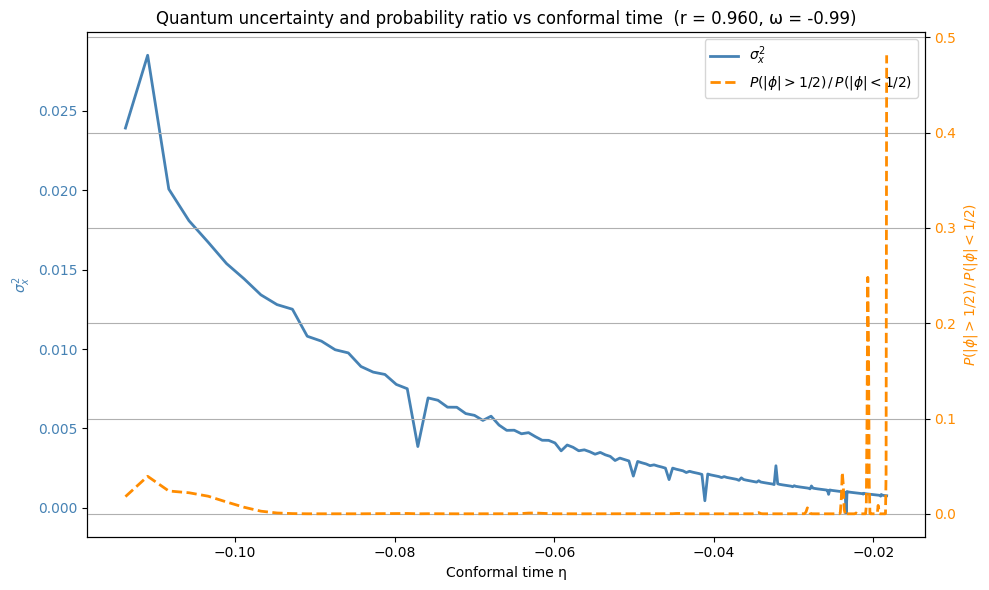

In [62]:
# Run the distribution for 5 different eta's at a fixed r
R_plot = 0.96
phi_range, psi_vals, phi_cl, sig_sq = run_distribution_eta(a_grid, R_plot)

# Run the logic for going over all eta values at fixed r for probability ratios
eta_arr, phi_cl_arr, sig_sq_arr, ratio_arr = run_prob_ratio_all_eta(a_grid, R_plot)

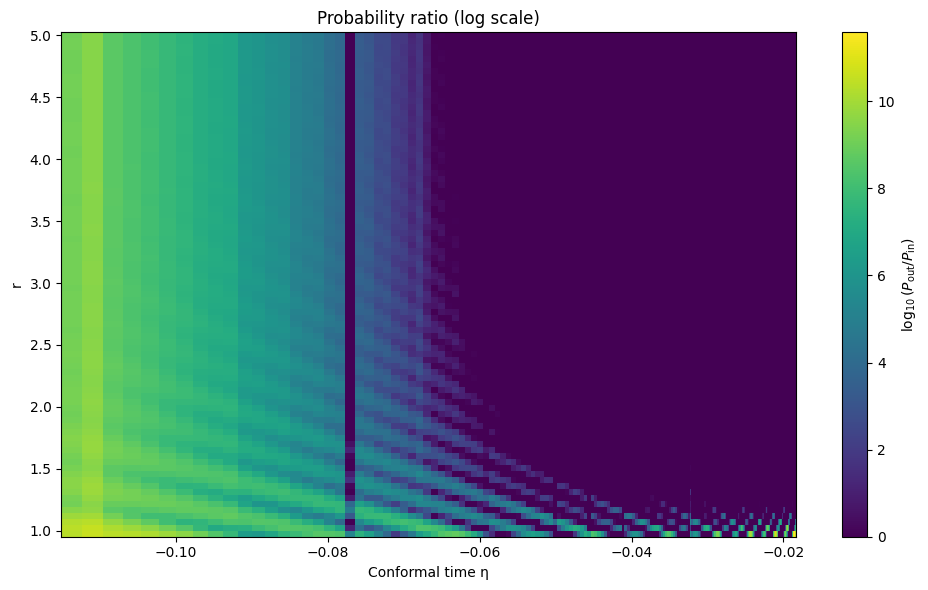

In [63]:
# Run the part for the heatmap of the probability ratio
eta_vals, r_vals, R_matrix = run_prob_ratio_all_r(a_grid, r_grid)
plot_ratio_heatmap(eta_vals, r_vals, R_matrix)

C:\Users\guusb\AppData\Local\Temp\ipykernel_11080\1345177912.py:342: RuntimeWarning: invalid value encountered in log10
  log_sig = np.log10(sig_safe + 1e-30)


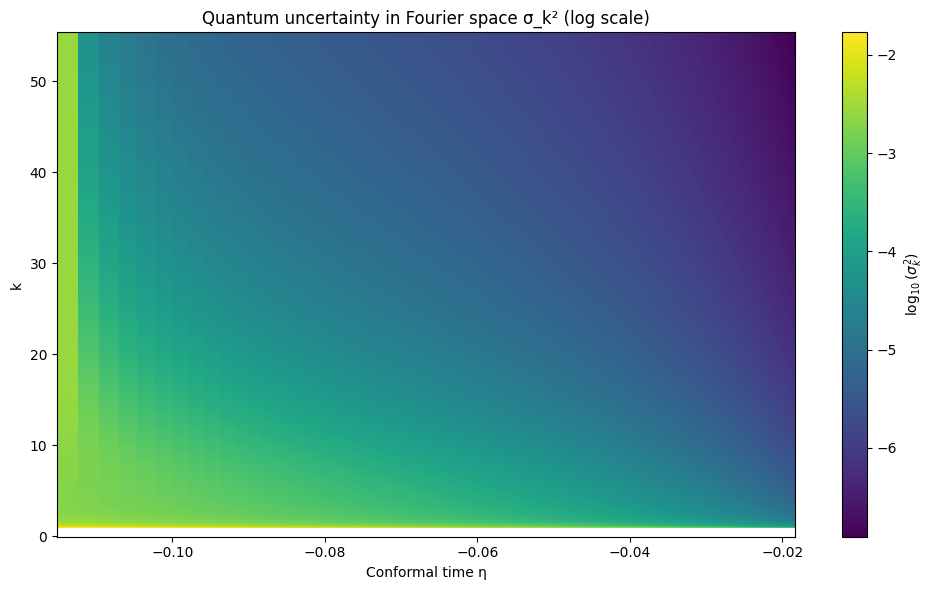

In [64]:
# Run the part for plotting the heatmap of the uncertainty in Fourier space
eta_vals, k_vals, sigma_k_mat = run_uncertainty_Fourier(a_grid, NK)
plot_sigma_k_heatmap(eta_vals, k_vals, sigma_k_mat)

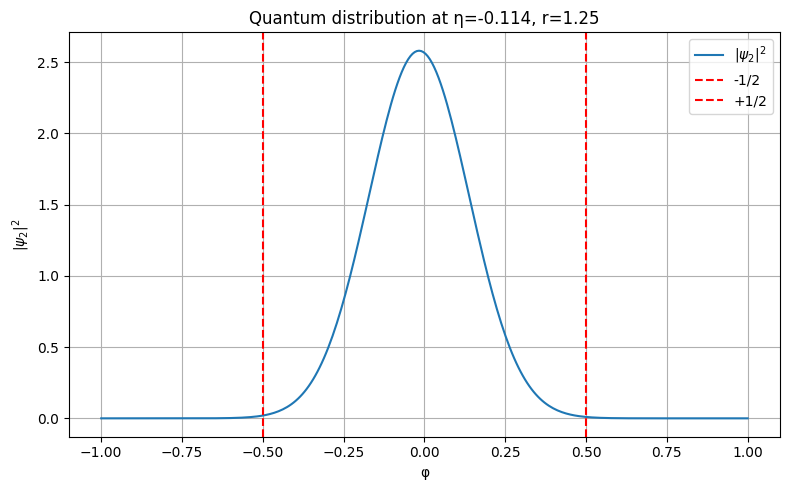

eta=-0.11375, phi_cl=-0.01675, sigma_x²=0.02392


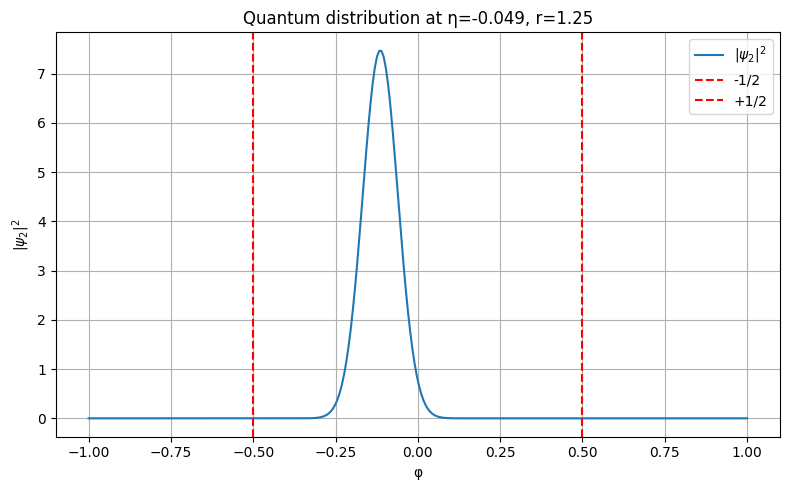

eta=-0.04915, phi_cl=-0.11409, sigma_x²=0.00285


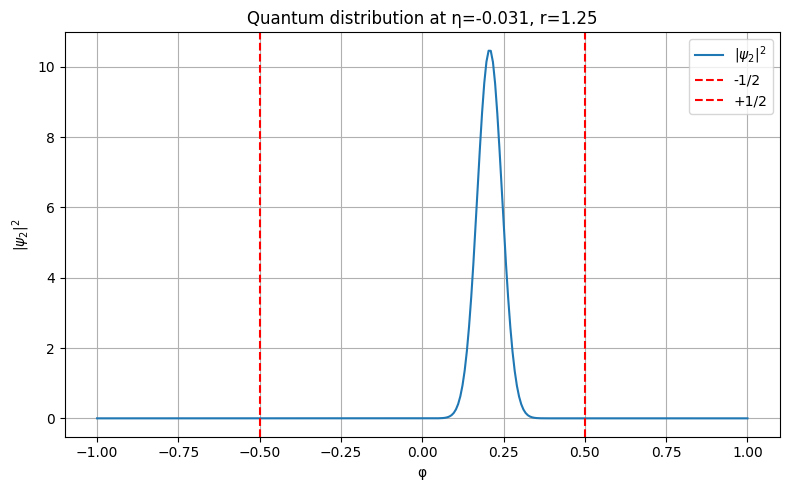

eta=-0.03145, phi_cl=0.20729, sigma_x²=0.00144


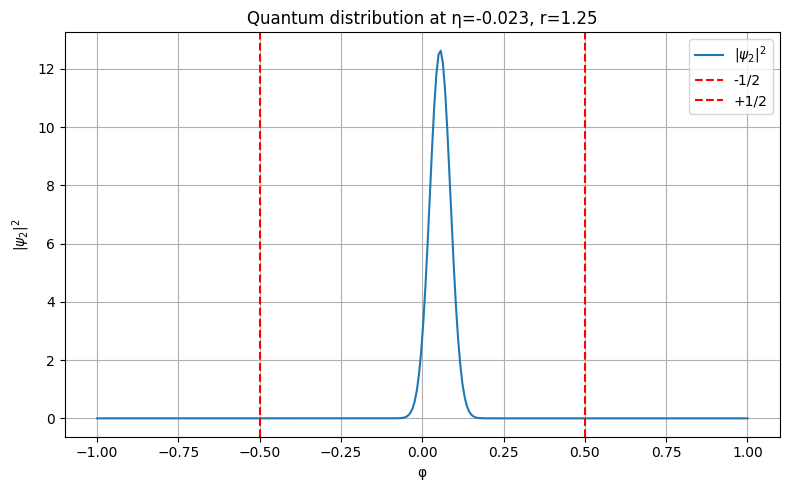

eta=-0.02316, phi_cl=0.05501, sigma_x²=0.00100


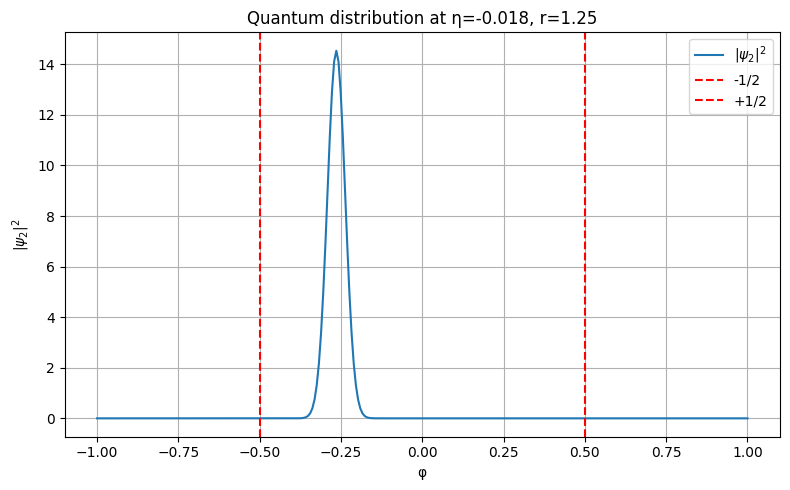

eta=-0.01834, phi_cl=-0.26424, sigma_x²=0.00075


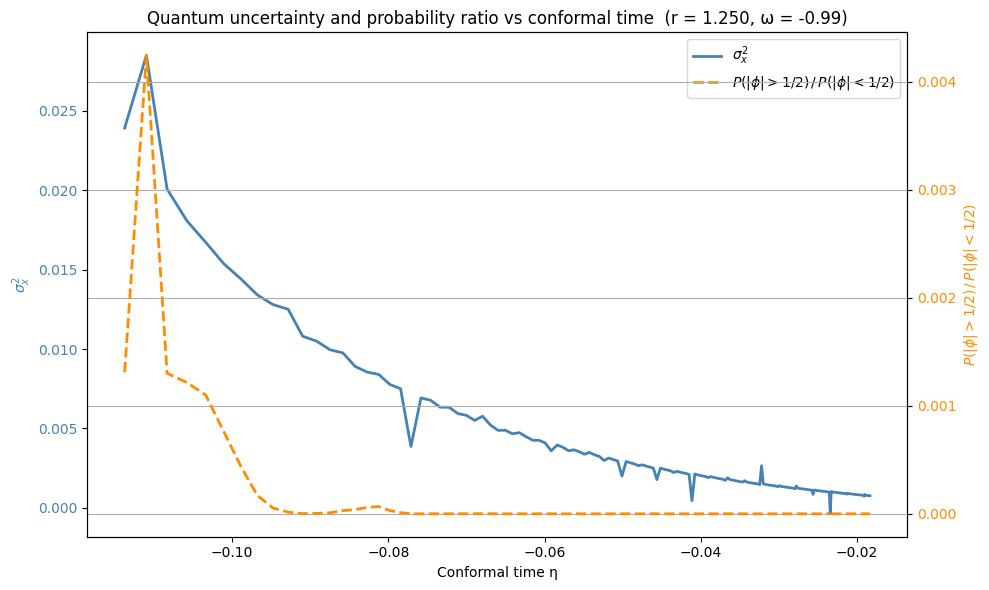

In [65]:
# Run the distribution for 5 different eta's at a fixed r
R_plot_2 = 1.25
phi_range, psi_vals, phi_cl, sig_sq = run_distribution_eta(a_grid, R_plot_2)

# Run the logic for going over all eta values at fixed r for probability ratios
eta_arr, phi_cl_arr, sig_sq_arr, ratio_arr = run_prob_ratio_all_eta(a_grid, R_plot_2)

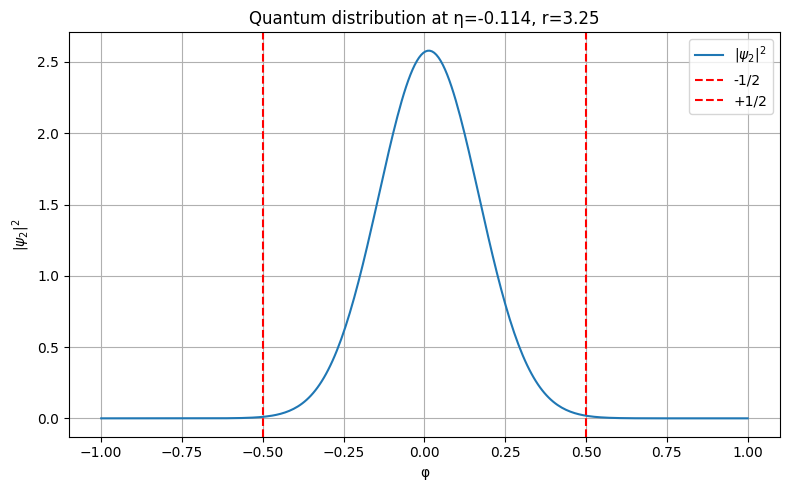

eta=-0.11375, phi_cl=0.01354, sigma_x²=0.02392


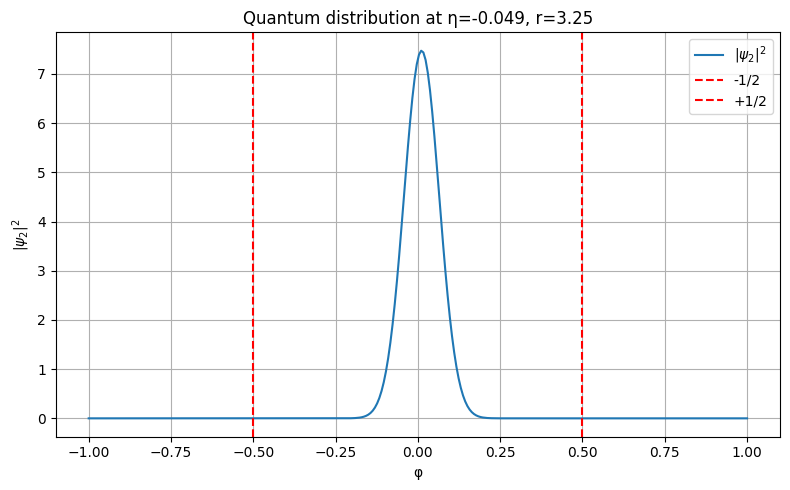

eta=-0.04915, phi_cl=0.01133, sigma_x²=0.00285


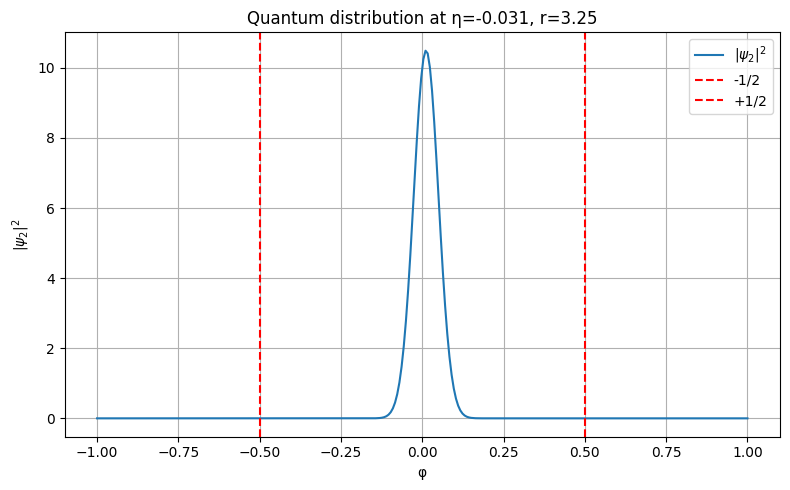

eta=-0.03145, phi_cl=0.01177, sigma_x²=0.00144


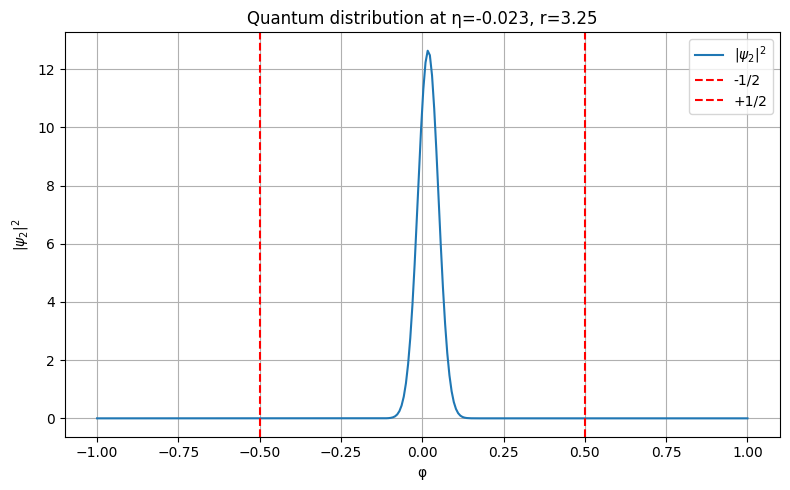

eta=-0.02316, phi_cl=0.01823, sigma_x²=0.00100


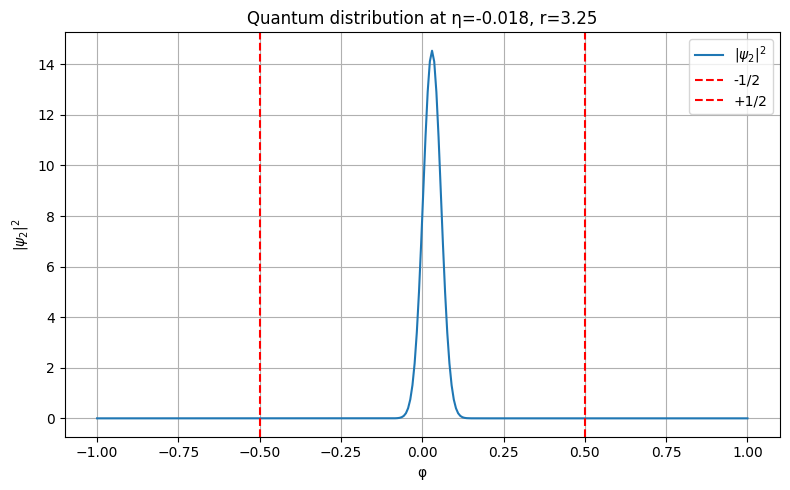

eta=-0.01834, phi_cl=0.03007, sigma_x²=0.00075


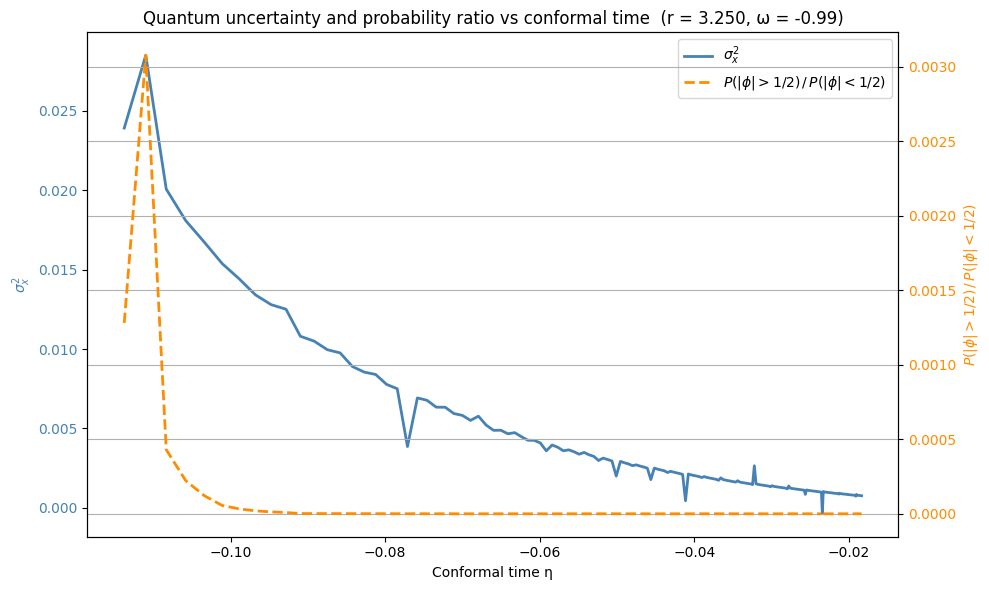

In [66]:
# Run the distribution for 5 different eta's at a fixed r
R_plot_3 = 3.25
phi_range, psi_vals, phi_cl, sig_sq = run_distribution_eta(a_grid, R_plot_3)

# Run the logic for going over all eta values at fixed r for probability ratios
eta_arr, phi_cl_arr, sig_sq_arr, ratio_arr = run_prob_ratio_all_eta(a_grid, R_plot_3)